# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [4]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv('./data/tweet_sentiment_train.csv.zip')

raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [7]:
raw_df = raw_df.dropna()
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [12]:
raw_df['sentiment'].value_counts(normalize=True)

sentiment
neutral     0.404549
positive    0.312300
negative    0.283151
Name: proportion, dtype: float64

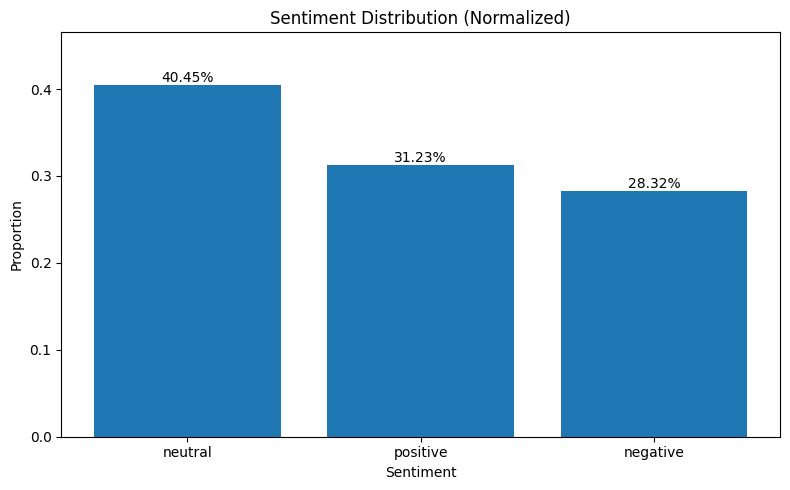

In [13]:
import matplotlib.pyplot as plt

# Compute distribution
sentiment_dist = raw_df['sentiment'].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_dist.index, sentiment_dist.values)

plt.title('Sentiment Distribution (Normalized)')
plt.xlabel('Sentiment')
plt.ylabel('Proportion')

# Value labels
for bar, value in zip(bars, sentiment_dist.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.2%}',
        ha='center',
        va='bottom'
    )

plt.ylim(0, sentiment_dist.max() * 1.15)
plt.tight_layout()
plt.show()

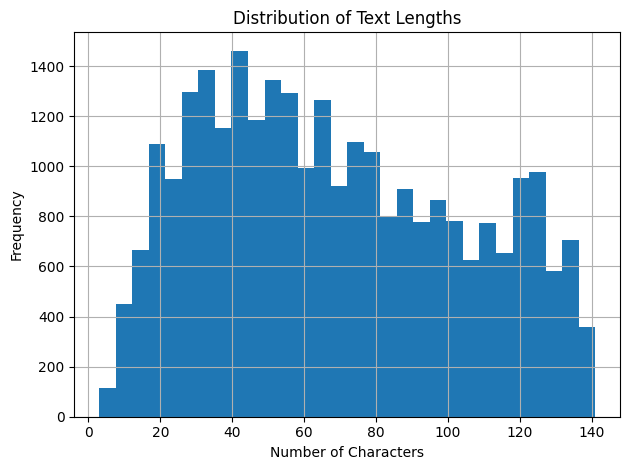

In [20]:
text_length = pd.Series(raw_df['text'].apply(lambda t: len(t)))

ax = text_length.hist(bins=30)
ax.set_title('Distribution of Text Lengths')
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [21]:
text_length.describe()

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text, dtype: float64

<span style="display: block; background-color: #f60">

* The dataset shows **no significant class imbalance**: *neutral* accounts for ~40% of samples, while *positive* (~31%) and *negative* (~28%) are relatively close in proportion. This distribution is sufficiently balanced for training standard classifiers without requiring resampling techniques.
* Post lengths range from **3 to 141 characters**, with a clear primary peak around **40 characters**. The shape loosely resembles a Poisson-like distribution, but the presence of a secondary peak near **120 characters** suggests a **bimodal pattern**, likely indicating two typical writing styles or message formats within the data.

</span>


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [ ]:
# first vectorize all possbile punctuations used to see the list
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_puncts = CountVectorizer(
    token_pattern=r"[^\w\s]+",   # sequences of punctuation
    lowercase=False,
    max_features=300,
)

vectorizer_puncts.fit(raw_df.text)

vectorizer_puncts.get_feature_names_out()

array(['!', '!!', '!!!', '!!!!', '!!!!!', '!!!!!!', '!!!!!!!', '!!!!!!!!',
       '!!!!!!!!!', '!!!!!!!!!!', '!!!!!!!!!!!', '!!!!!!!!!!!!',
       '!!!!!!!!!!!!!', '!!!!!!!!!!!!!!', '!!!!!!!!!!!!!!!!!!!!!!',
       '!!!)', '!!!..', '!!!...', "!!'", '!!)', '!!...', '!!?', '!!??',
       "!'", '!)', '!),', '!).', '!*', '!,', '!,.', '!.', '!..', '!...',
       '!.....', '!:', '!?', '!?!', '!?!?', '!?!?!', '!?!?!?!?', '!??',
       '!]', '!`', '#', '#****', '$', '$$', '$$$', '$.', '%', '%),', '%.',
       '&', '&&', "'", "'!", "'!!!", "''", "',", "'-", "'.", "'...",
       "'....", "'?", '(', '($', '(&', "('", '((', '(((', '()', '(*',
       '(****', '(****)', '(:', '(?)', ')', ')!', '))', ')))', '),', ').',
       ')..', ')...', '):', ')?', '*', "*'", '**', '***', '****', '****!',
       '****!!', '****!!!!', '*****', '****,', '****-', '****.', '****..',
       '****...', '****....', '****?', '****`', '*-*', '*.', '*...', '*~',
       '+', ',', ',,', ',,,', ',.', ',..', ',...', '-', '-)',

In [ ]:
# next check numbers related stuff
vectorizer_num = CountVectorizer(
    token_pattern=r"\b(?:\d{1,3}%|\d+/\d+|[a-z]*\d+[a-z]*)\b",  # try to find something meaninful related to numbers
    lowercase=False,
    max_features=1000,
)

vectorizer_num.fit(raw_df.text)

vectorizer_num.get_feature_names_out()

array(['0', '00', '000', '000th', '00am', '00pm', '01', '02', '024',
       '02mxjj', '03', '04', '04/05', '05', '05/30', '05/31', '05ixbj',
       '06', '060', '0600', '06am', '07', '07am', '08', '08kaifj', '09',
       '097dfj', '0f', '0guyoj', '0k', '0mqko', '0n', '0zywwj', '1',
       '1/2', '10', '100', '1000', '10000000000',
       '100000000000000000000000000000000000', '1000th', '1000x',
       '100greatestgames', '100msg', '100th', '100x', '101', '1017',
       '102', '103', '1030', '1034415', '104', '105', '106', '107', '108',
       '109', '1095', '10am', '10days', '10jsepj', '10k', '10m', '10mins',
       '10mm', '10pm', '10th', '10yr', '11', '11/20', '110', '1100',
       '1115', '1123', '1130', '1155hours', '116', '117th', '11am', '11e',
       '11pm', '11th', '11w', '12', '120', '121908inlove', '123', '128',
       '12seconds', '12st', '12th', '12yr', '13', '130', '1300', '131',
       '132', '13576/658166', '14', '140', '143', '145', '14th', '15',
       '150', '1500', 

<span style="display: block; background-color: #f60">

* The raw text contains a large amount of **noise from numbers, punctuation, IDs, and random character sequences**. Most of this does not carry semantic or sentiment value and will be **removed during tokenization** to reduce vocabulary pollution and sparsity.
* Certain punctuation patterns, however, act as **strong sentiment signals in short texts**. Instead of dropping them, they will be **normalized and preserved** under six canonical tokens:

  * **ELLIPSIS** — sequences of dots (`..`, `...`, `....`) indicating hesitation, sadness, or trailing emotion
  * **EXCL** — repeated exclamation marks (`!`, `!!`, `!!!`) expressing strong emotion or emphasis
  * **QUEST** — repeated question marks (`?`, `??`, `???`) indicating confusion, disbelief, or frustration
  * **MIXED_QE** — mixed `?!` patterns expressing emotional confusion or shock
  * **SMILE** — emoticons ending with positive mouth shapes (`:)`, `:D`, `:>`, `:-*`) indicating positive emotion
  * **FROWN** — emoticons ending with negative/neutral mouth shapes (`:(`, `:/`, `:-|`, `:<`) indicating negative or neutral emotion
* Numeric tokens are mostly noisy, but a small subset behaves like **meaningful words** (e.g., `2day`, `4ever`, `24/7`, `100`, `404`). A **whitelist of such tokens** will be preserved during tokenization, while all other numbers will be removed.

</span>


In [156]:
NUM_KEEP = {
    # emphasis / rating
    '100', '1000', '100x', '10/10', '1/2',

    # time-of-day (mood context)
    '4am', '5am', '6am', '7am', '8am', '9am',
    '10am', '11am', '1am', '2am', '3am',
    '4pm', '5pm', '6pm', '7pm', '8pm', '9pm', '10pm', '11pm',

    # short time expressions
    '24/7', '24hrs', '24hr', '48hours', '60s',

    # slang / leetspeak / SMS language
    '2day', '2moro', '2morrow', '2mrw', '2nite', '2night', '2nyt',
    '4ever', 'l8', 'l8r', 'l8rs', 'l8ter',
    'gr8', 'b4', 'w8', 'm8', 'h8', 'g2g',

    # common “word-like” number tokens
    '3d', '3ds', 'mp3', 'mp4', 'ps3',

    # culturally meaningful numbers
    '404', '911', '420', '365',

    # durations people complain about
    '10mins', '15mins', '20mins', '30mins',
    '1hr', '2hrs', '3hrs', '6hrs',

    # ages / years-as-words (often sentiment context)
    '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s',
}

In [157]:
import re

SMILE_RE = re.compile(r"""
    (?:
        [:;]      # eyes
        -?        # optional nose
        [)\]>D*]  # happy mouth
    )
""", re.VERBOSE)

FROWN_RE = re.compile(r"""
    (?:
        [:;]      # eyes
        -?        # optional nose
        [(\[</|]  # sad/neutral mouth
    )
""", re.VERBOSE)

def pre_normalize(text):
    text = SMILE_RE.sub(" SMILE ", text)
    text = FROWN_RE.sub(" FROWN ", text)

    text = re.sub(r"[!?]{2,}", " MIXED_QE ", text)
    text = re.sub(r"\.{2,}", " ELLIPSIS ", text)
    text = re.sub(r"!{1,}", " EXCL ", text)
    text = re.sub(r"\?{1,}", " QUEST ", text)
    return text

In [158]:
# test it 
pre_normalize(';))'), pre_normalize(':]'), pre_normalize(':>'), pre_normalize(':-*'), 

(' SMILE )', ' SMILE ', ' SMILE ', ' SMILE ')

In [159]:
# test it 
pre_normalize(':-/'), pre_normalize(':-|'), pre_normalize(':/'), pre_normalize('://'), pre_normalize(':<'), 

(' FROWN ', ' FROWN ', ' FROWN ', ' FROWN /', ' FROWN ')

In [160]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import re

word_re = re.compile(r"^[a-zA-Z]{2,}$")
stemmer = SnowballStemmer(language='english')
english_stopwords = stopwords.words('english')

def tokenize(text):
    text = pre_normalize(text.lower())
    tokens = word_tokenize(text)

    result = []
    for t in tokens:
        if t in {"ELLIPSIS","EXCL","QUEST","MIXED_QE","SMILE","FROWN"}:
            result.append(t)
        elif t in NUM_KEEP:
            result.append(t)
        elif word_re.match(t) and t not in english_stopwords:
            result.append(stemmer.stem(t))

    return result

In [161]:
vectorizer = CountVectorizer(
    analyzer='word',
    lowercase=True,
    tokenizer=tokenize,
    max_features=2000,      # keep only 2000 most popular as features
)

In [162]:
%%time
vectorizer.fit(raw_df.text)

CPU times: user 2.89 s, sys: 32.1 ms, total: 2.92 s
Wall time: 2.97 s


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function tok...t 0x1394e0b80>
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [163]:
vectorizer.get_feature_names_out()[:100]

array(['1/2', '100', '2day', '2moro', '2nite', '3d', '4am', '7am', '9am',
       'ELLIPSIS', 'EXCL', 'FROWN', 'MIXED_QE', 'QUEST', 'SMILE', 'abl',
       'absolut', 'abt', 'ac', 'accept', 'access', 'accid', 'accident',
       'accord', 'account', 'ace', 'ach', 'across', 'act', 'action',
       'activ', 'actual', 'ad', 'adam', 'add', 'addict', 'address',
       'admit', 'adopt', 'ador', 'advanc', 'adventur', 'advic', 'afford',
       'afraid', 'afternoon', 'age', 'ago', 'agre', 'ah', 'aha', 'ahaha',
       'ahead', 'ahh', 'ahhh', 'ahhhh', 'aim', 'aint', 'air', 'airport',
       'al', 'ala', 'alarm', 'album', 'alcohol', 'alex', 'aliv',
       'allergi', 'allow', 'almost', 'alon', 'along', 'alot', 'alreadi',
       'alright', 'also', 'although', 'alway', 'amaz', 'america',
       'american', 'ami', 'amus', 'andi', 'ang', 'angel', 'angri', 'anim',
       'ankl', 'anna', 'anniversari', 'announc', 'annoy', 'anoth',
       'answer', 'anybodi', 'anymor', 'anyon', 'anyth', 'anytim'],
      dtyp

In [164]:
%%time
inputs = vectorizer.transform(raw_df.text)

CPU times: user 2.89 s, sys: 28 ms, total: 2.91 s
Wall time: 2.99 s


In [165]:
inputs.shape

(27480, 2000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model